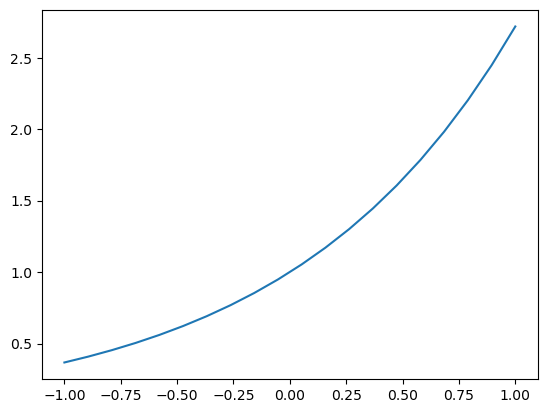

In [1]:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(-1,1,20)
y = np.exp(x)
fig, ax = plt.subplots()
ax.plot(x,y)



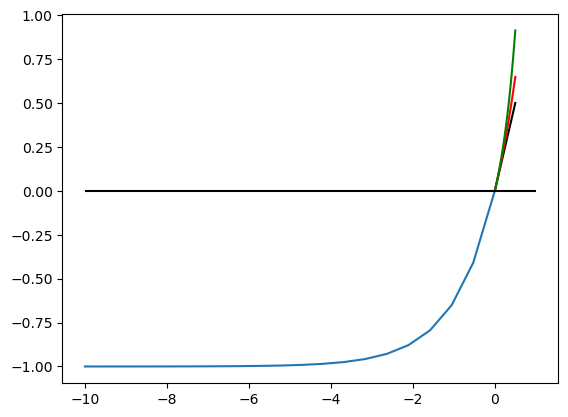

In [2]:
logicalQubits = np.linspace(-10,0,20)
reward = np.linspace(0,0.5,10)
y = np.exp(logicalQubits) -1
fig, ax = plt.subplots()
ax.plot(logicalQubits ,y)
ax.plot(reward, reward, color = "black")
ax.plot(reward, np.exp(reward) - 1, color = "red")
ax.plot(reward, np.exp(np.exp(reward) - 1)-1, color="green")
ax.plot()
ax.hlines(0,-10,1, colors="black")

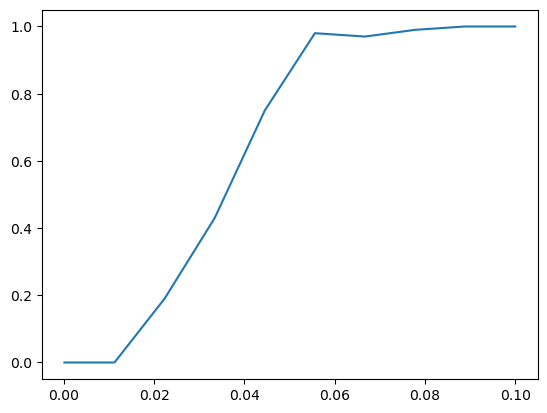

In [14]:
# Omer: Do not repurpose the following code, it's meant to check that BpOsdDecoder behaves correctly if the error probability changes

import numpy as np
from ldpc import BpOsdDecoder
from qecc.logicals import computeLogicals
from qecc.polynomialCodes import codes#["Hx_72_12_6"]
#from qecc.polynomialCodes import codes["Hz_72_12_6"]
from qecc.gf4 import integerToDualBinary
import matplotlib.pyplot as plt
Hx,Hz = codes["Hx_72_12_6"], codes["Hz_72_12_6"]

seed = 0
localRandom = np.random.RandomState(seed) 

logicalX, logicalZ = computeLogicals(Hx, Hz)

numberOfIterations = 50
numberOfSamples = 100

ms_scaling_factor = 0.625
errorRange = np.linspace(0.0001,0.1,10).astype(float)
logicalErrorRate = np.zeros(len(errorRange))
bpDecoderHx=BpOsdDecoder(Hx,#the parity check matrix
                            error_rate=1.0,
                                #channel_probs= initialValues[:,1], #assign error_rate to each qubit. This will override "error_rate" input variable
                            max_iter=numberOfIterations, #the maximum number of iterations for BP)
                            bp_method="ms",
                            ms_scaling_factor=ms_scaling_factor, #min sum scaling factor. If set to zero the variable scaling factor method is used
                            osd_method="osd0", #the OSD method. Choose from:  1) "osd_e", "osd_cs", "osd0"
                            osd_order=0 #the osd search depth
                            )
bpDecoderHz=BpOsdDecoder(Hz,#the parity check matrix
                            error_rate=1.0,
                            #channel_probs= initialValues[:,1], #assign error_rate to each qubit. This will override "error_rate" input variable
                            max_iter=numberOfIterations, #the maximum number of iterations for BP)
                            bp_method="ms",
                            ms_scaling_factor=ms_scaling_factor, #min sum scaling factor. If set to zero the variable scaling factor method is used
                            osd_method="osd0", #the OSD method. Choose from:  1) "osd_e", "osd_cs", "osd0"
                            osd_order=0 #the osd search depth
                            )
for i in range(len(errorRange)):
    p = float(errorRange[i])
    bpDecoderHx.error_rate = p
    bpDecoderHz.error_rate = p
    # bpDecoderHx=BpOsdDecoder(Hx,#the parity check matrix
    #                         error_rate=p,
    #                             #channel_probs= initialValues[:,1], #assign error_rate to each qubit. This will override "error_rate" input variable
    #                         max_iter=numberOfIterations, #the maximum number of iterations for BP)
    #                         bp_method="ms",
    #                         ms_scaling_factor=ms_scaling_factor, #min sum scaling factor. If set to zero the variable scaling factor method is used
    #                         osd_method="osd0", #the OSD method. Choose from:  1) "osd_e", "osd_cs", "osd0"
    #                         osd_order=0 #the osd search depth
    #                         )
    # bpDecoderHz=BpOsdDecoder(Hz,#the parity check matrix
    #                         error_rate=p,
    #                         #channel_probs= initialValues[:,1], #assign error_rate to each qubit. This will override "error_rate" input variable
    #                         max_iter=numberOfIterations, #the maximum number of iterations for BP)
    #                         bp_method="ms",
    #                         ms_scaling_factor=ms_scaling_factor, #min sum scaling factor. If set to zero the variable scaling factor method is used
    #                         osd_method="osd0", #the OSD method. Choose from:  1) "osd_e", "osd_cs", "osd0"
    #                         osd_order=0 #the osd search depth
    #                         )
    
    
    for _ in range(numberOfSamples):
        #Sample (some number of times) an error, which is a vector over {0,1,2,3} representing I,X,Z,Y (to be consistent check with the documentation in gf4.py)
        error = localRandom.choice([0,1,2,3], size=Hx.shape[1], replace=True, p=[1 - 3*p, p, p, p])
        errorX, errorZ = integerToDualBinary(error)
        #Calculate the syndrome for this error
        
        estimatedErrorX = bpDecoderHz.decode(Hz.dot(errorX)%2)
        estimatedErrorZ = bpDecoderHx.decode(Hx.dot(errorZ)%2)
        residualErrorX = (estimatedErrorX + errorX) % 2
        residualErrorZ = (estimatedErrorZ + errorZ) % 2
        # Check whether the residual error gives 0 syndrome:
        if not ( np.all((np.dot(Hx,residualErrorZ)) % 2 ==0) and np.all((np.dot(Hz, residualErrorX)%2) == 0)):
            #print("Decoder failure: the residual error does not give 0 syndrome, meaning the decoder is wrong")
            logicalErrorRate[i] += 1
        else: # So we are in the case that the residual error commutes with all stabilizers, i.e., it is in the normalizer. So let's check if it is a stabilizer (commutes with all logicals), or a logical error (anticommutes with some logical operator)
            if not ( np.all((np.dot(logicalZ,residualErrorX) % 2 )== 0) and np.all((np.dot(logicalX, residualErrorZ) % 2)==0)):
                #print(f"Logical error: the residual error commutes with all stabilizers but anticommutes with some logical operator")
                logicalErrorRate[i] += 1
logicalErrorRate = logicalErrorRate / numberOfSamples            
 
plt.plot(errorRange, logicalErrorRate)